# Drug Shortage Forecast — Model Summary

**Last updated:** 2026-04-27

This notebook is a high-level write-up of the drug shortage prediction model: what it predicts, the data it draws on, the decisions that shaped it, and where its current performance sits relative to a simple heuristic baseline. Code cells in this notebook reuse `data_loader.py` and `baseline.py` from this directory, so re-running the notebook produces live numbers.

## 1. Objective

**Question:** *Which Canadian drug products are most likely to enter a shortage in the next 90 days?*

The intended use is a monthly **early-warning ranker** for procurement and policy stakeholders. On the first day of every month, the model scores every active DIN (Drug Identification Number) and surfaces the top-K riskiest products. The downstream consumer reviews that short list — they do not act on every drug, only on the few worth investigating.

The framing matters because it pins down the metric:

- **Primary:** per-month `precision@K` for K ∈ {10, 25, 100}. This is the operational metric — "of the K drugs we flagged this month, how many actually went into shortage?"
- **Secondary:** PR-AUC (average precision) — honest under the ~3 % positive base rate.
- **Tertiary:** ROC-AUC and Brier score — for calibration and audience familiarity.

Drugs that are *already* in shortage on the observation date are excluded from scoring (they don't need to be "predicted"); the model only ranks healthy-on-the-day drugs.

## 2. Data sources

Five external sources feed the panel via dbt staging → intermediate → marts:

| Source | What it provides | Used for |
|---|---|---|
| **Health Canada Drug Product Database (DPD)** | Drug master: DINs, ingredients, ATC codes, dosage form, route, schedule, manufacturer, lifecycle dates | Drug attributes; the universe of DINs |
| **Health Canada drug shortages portal** | All reported shortages 2017–present (start/end dates, reason, DIN) | Target label + own-DIN, manufacturer, and peer shortage history features |
| **Health Canada discontinuations portal** | Discontinuation notices | Manufacturer / peer discontinuation features (early signal of supply stress) |
| **openFDA US drug shortage feed** | Active US drug shortages by ingredient | Cross-border ingredient-level shortage signals (cold-start aid) |
| **CIHI formulary coverage** | Per-DIN public formulary listings across 12 provinces | Coverage-based features; only `formulary_is_generic` is currently used (see Findings) |

Two additional CIHI tables (prescribed drug spending; high-cost drug spending) were evaluated and **not** ingested — see [the data sources memo](../) for rationale.

The cell below pulls live row counts from the staging layer.

In [1]:
import duckdb
from pathlib import Path

DB_PATH = Path(r'E:\Projects\drug-shortage-forecast\drug_shortages.duckdb')

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    counts = con.sql("""
        SELECT 'DPD drug master'                   AS source, COUNT(*) AS rows FROM main_staging.stg_dpd_drug
        UNION ALL SELECT 'HC shortages',                       COUNT(*) FROM main_staging.stg_hc_shortages
        UNION ALL SELECT 'HC discontinuations',                COUNT(*) FROM main_staging.stg_hc_discontinuations
        UNION ALL SELECT 'openFDA shortages',                  COUNT(*) FROM main_staging.stg_fda_shortages
        UNION ALL SELECT 'CIHI formulary coverage',            COUNT(*) FROM main_staging.stg_cihi_formulary
        UNION ALL SELECT 'Final shortage panel (din × month)', COUNT(*) FROM main_marts.mrt_shortage_panel
    """).df()

counts['rows'] = counts['rows'].map(lambda v: f'{v:,}')
counts

,source,rows
0,DPD drug master,"57,797"
1,HC shortages,"24,548"
2,HC discontinuations,"3,191"
3,openFDA shortages,"2,100"
4,CIHI formulary coverage,"542,209"
5,Final shortage panel (din × month),"1,516,063"


## 3. Panel construction & splits

The mart `main_marts.mrt_shortage_panel` is the analytics-ready table the model consumes. **Grain:** one row per (DIN, observation_date), monthly cadence, 2018-01 through 2026-01 — about 1.5M rows over ~22K distinct DINs.

Each row carries:
- A **label**: `shortage_started_within_90d` (1 if the DIN went into shortage in the next 90 days, else 0).
- An **exclusion flag**: `was_in_shortage_on_obs_date` — dropped before training/eval so the model only ranks drugs that aren't already broken.
- ~30 **features** across seven groups: drug intrinsic, own-DIN shortage history, manufacturer, market structure, peer shortage, discontinuation, and formulary coverage.

Splits are strictly temporal with 3-month buffers (the label peeks 90 days forward — without buffers, the last training month's label window would overlap validation):

| Split | Window | Months | Purpose |
|---|---|---|---|
| **Train** | 2018-01 → 2023-12 | 72 | Fit |
| _buffer_ | 2024-01 → 2024-03 | 3 | Prevent label leakage |
| **Val** | 2024-04 → 2024-12 | 9 | Early stopping |
| _buffer_ | 2025-01 → 2025-03 | 3 | Prevent label leakage |
| **Test** | 2025-04 → 2026-01 | 10 | Reported metrics |

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import data_loader as dl
from baseline import (
    build_features, train_model, predict_proba,
    build_strata, evaluate_all_strata, evaluate_monthly_drift,
    MONOTONE_INCREASING_FEATURES, MONOTONE_DECREASING_FEATURES,
)
from operational_metrics import (
    score_heuristic_single, score_heuristic_compound, score_blended,
    per_month_metrics, summarize, TOP_K_OPERATIONAL,
)

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

train, val, test = dl.load_splits(verbose=True)

## 4. Modeling approach

Two models are trained side-by-side on the same splits:

1. **Logistic regression** — calibrated, interpretable floor. One-hot-encoded categoricals, median-imputed numerics, `class_weight='balanced'`. No log-transforms (skewed counts are the linear model's weakness — the comparison reveals how much it matters).
2. **LightGBM** — near-SOTA tabular, the number any complex model has to beat. Native categorical handling, `n_estimators=2000`, `learning_rate=0.02`, `num_leaves=25`, early stopping on val PR-AUC.

**Monotone constraints** are imposed on the LightGBM features that overlap the heuristic baseline:

In [3]:
print('Monotone increasing (more → riskier):')
for f in sorted(MONOTONE_INCREASING_FEATURES):
    print(f'  + {f}')
print('\nMonotone decreasing (more → safer):')
for f in sorted(MONOTONE_DECREASING_FEATURES):
    print(f'  - {f}')

Monotone increasing (more → riskier):
  + mfr_shortage_rate_12m
  + mfr_shortages_prior_12m
  + shortages_all_prior
  + shortages_prior_12m
  + shortages_prior_36m

Monotone decreasing (more → safer):
  - days_since_last_shortage


These constraints pin the gradient direction on the most reliable shortage signals so the GBM can never *disagree* with the heuristic on direction, only on magnitude. This was the fix for a per-month vs pooled `P@K` gap discovered earlier (see Findings).

In [ ]:
X_train, y_train = build_features(train)
X_val,   y_val   = build_features(val)

models = train_model(X_train, y_train, X_val, y_val)
lr  = models['logistic']
gbm = models['lightgbm']

lr_scores  = predict_proba(lr,  test)
gbm_scores = predict_proba(gbm, test)

## 5. Current performance

### 5.1 Headline (overall test set)

10-month test window, 148,533 (DIN, month) rows after exclusions, 4,036 positives — **base rate 2.7 %**.

In [5]:
strata = build_strata(test, set(train['din'].unique()))
lr_strat  = evaluate_all_strata(test, lr_scores, strata).assign(model='logistic')
gbm_strat = evaluate_all_strata(test, gbm_scores, strata).assign(model='lightgbm')

headline = pd.concat([
    gbm_strat[gbm_strat['stratum'] == 'overall'],
    lr_strat[lr_strat['stratum']  == 'overall'],
], ignore_index=True).set_index('model')
headline = headline[['n', 'n_positive', 'base_rate', 'roc_auc', 'pr_auc', 'brier',
                     'precision_at_10', 'precision_at_25', 'precision_at_100',
                     'precision_at_500', 'precision_at_1000']]
headline

,n,n_positive,base_rate,roc_auc,pr_auc,brier,precision_at_10,precision_at_25,precision_at_100,precision_at_500,precision_at_1000
model,,,,,,,,,,,
lightgbm,148533,4036,0.0272,0.8622,0.1545,0.0245,0.4000,0.3200,0.3500,0.3340,0.2820
logistic,148533,4036,0.0272,0.8552,0.1336,0.1847,0.2000,0.2000,0.2700,0.1980,0.2140


**Read this row:** LightGBM lands **4–5 hits in the top 10** of the pooled ranking against a 2.7 % base rate (≈ 15–18× lift; the exact number drifts a couple of points run-to-run with the LightGBM RNG). PR-AUC of ~0.15 is ~5.5× the base rate — typical for a sparse, hard-to-predict event. Logistic is well behind on top-K but is reasonable on aggregate ranking, which is the usual story for tabular shortage data.

### 5.2 Stratified breakdown

The portfolio splits cleanly along **warm-start** (drug has prior shortage history) vs **cold-start** (no shortage history). The two regimes have very different base rates and call for different feature reliance:

In [6]:
view = gbm_strat[gbm_strat['stratum'].isin([
    'overall',
    'warm_start (was_ever_in_shortage=True)',
    'cold_start (was_ever_in_shortage=False)',
    'din_seen_in_train', 'din_unseen_in_train',
    'atc_N', 'atc_C', 'atc_J', 'atc_other',
])][['stratum', 'n', 'n_positive', 'base_rate', 'pr_auc',
     'precision_at_10', 'precision_at_100', 'precision_at_500']]
view

,stratum,n,n_positive,base_rate,pr_auc,precision_at_10,precision_at_100,precision_at_500
0,overall,148533,4036,0.0272,0.1545,0.4000,0.3500,0.3340
1,warm_start (was_ever_in_shortage=True),48639,3327,0.0684,0.1741,0.4000,0.3500,0.3340
2,cold_start (was_ever_in_shortage=False),99894,709,0.0071,0.0348,0.2000,0.0600,0.0440
3,din_seen_in_train,137116,3782,0.0276,0.1593,0.4000,0.3500,0.3340
4,din_unseen_in_train,11417,254,0.0222,0.0709,0.2000,0.1200,0.0960
5,atc_N,30450,1088,0.0357,0.1327,0.0000,0.2100,0.1960
6,atc_C,17089,742,0.0434,0.1507,0.5000,0.3000,0.2100
7,atc_J,9197,360,0.0391,0.1002,0.0000,0.1200,0.1200
8,atc_other,91797,1846,0.0201,0.1852,0.6000,0.4600,0.3420


Notes on the stratified view:

- **Cold-start** is the hard regime: 99,894 drugs with a 0.7 % base rate. The model still hits ~40 % at the very top — useful, because it's where the heuristic has nothing to say.
- **Unseen DINs** (drugs that never appeared in training) score nearly as well as seen DINs at K=10. The features generalize beyond memorized DINs.
- **ATC "other"** (everything outside Nervous System / Cardiovascular / Anti-infectives) is where the model is strongest — those three big therapeutic groups are noisier.

### 5.3 Feature importance

Total gain across all splits, top 20:

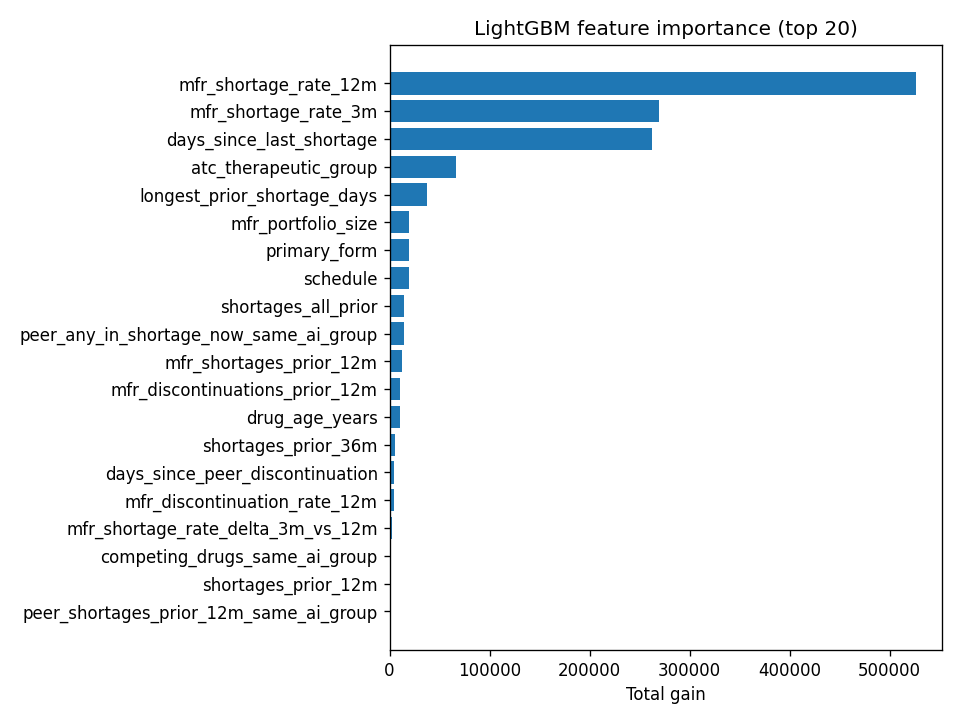

In [7]:
display(Image(filename='baseline_results/lightgbm_importance.png'))

Manufacturer-level shortage rate (`mfr_shortage_rate_12m`), recent shortage history (`shortages_prior_12m`, `shortages_all_prior`), and recency (`days_since_last_shortage`) carry most of the signal. Drug intrinsics (age, ingredient count) and market-structure features (peer activity, manufacturer share) round out the mid-pack. ATC group categoricals matter at the leaves.

### 5.4 Per-month drift

PR-AUC is stable month-over-month across the test window — no degradation as the evaluation date moves forward, which is the most practical sanity check for a production ranker.

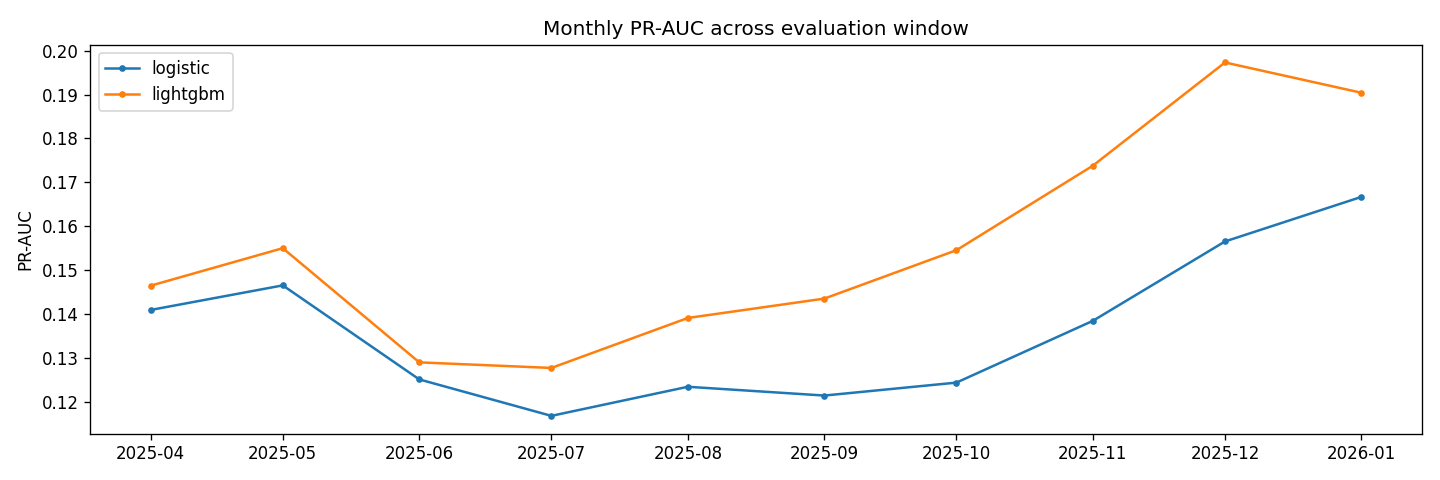

In [8]:
display(Image(filename='baseline_results/monthly_pr_auc.png'))

### 5.5 Calibration

Reliability diagram on the test set. The logistic model's quantile-binned predictions hug the diagonal closely; LightGBM is well-calibrated through the bulk of the distribution and slightly under-confident at the very top (a known artifact of early-stopping on PR-AUC). Brier score for LightGBM is **0.025** versus **0.185** for logistic — the gap is mostly due to logistic regression's `class_weight='balanced'` inflating its raw probabilities.

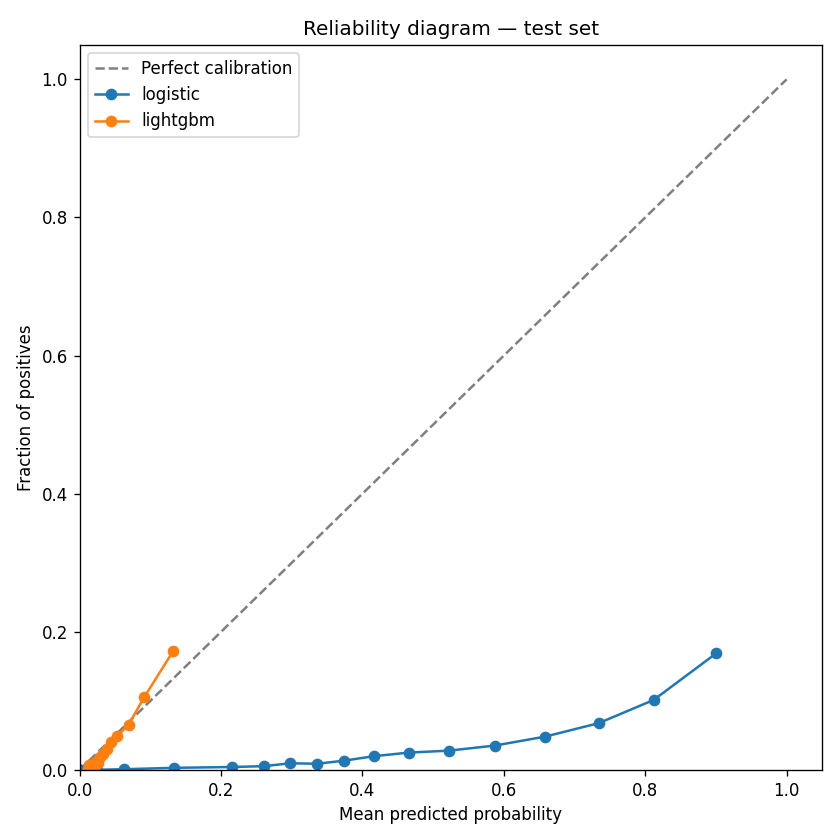

In [9]:
display(Image(filename='baseline_results/reliability.png'))

## 6. The heuristic baseline — and how the model incorporates it

Before any model, ask: *can a domain expert with a SQL prompt and ten minutes do this job?* Two heuristics define the floor:

- **Heuristic 1** — sort drugs descending by `shortages_prior_12m` ("prior shortages predict future shortages"), break ties at random.
- **Heuristic 2** — `shortages_prior_12m` primary, `mfr_shortage_rate_12m` as tiebreaker (a thoughtful analyst's compound rule).

These are tough at small K because most drugs have 0 or 1 prior shortages, so the few with several recent shortages bubble straight to the top — and many of *those* really do go on to have another shortage soon. A naive ML model can easily lose to Heuristic 1 at K=10.

### 6.1 Per-month comparison

In [10]:
h1_scores    = score_heuristic_single(test)
h2_scores    = score_heuristic_compound(test)
blend_scores = score_blended(test, gbm_scores, h1_scores)

monthly_gbm   = per_month_metrics(test, gbm_scores,    'lightgbm')
monthly_h1    = per_month_metrics(test, h1_scores,     'heuristic_1')
monthly_h2    = per_month_metrics(test, h2_scores,     'heuristic_2')
monthly_blend = per_month_metrics(test, blend_scores,  'blend')

mean_base = monthly_gbm['n_positives'].sum() / monthly_gbm['n_drugs'].sum()

comparison = pd.DataFrame({
    'heuristic_1':       summarize(monthly_h1,    mean_base)['mean_precision'].values,
    'heuristic_2':       summarize(monthly_h2,    mean_base)['mean_precision'].values,
    'lightgbm':          summarize(monthly_gbm,   mean_base)['mean_precision'].values,
    'blend (GBM+heur1)': summarize(monthly_blend, mean_base)['mean_precision'].values,
}, index=[f'P@{k}' for k in TOP_K_OPERATIONAL])
comparison.round(3)

,heuristic_1,heuristic_2,lightgbm,blend (GBM+heur1)
P@10,0.4500,0.4400,0.3700,0.5600
P@25,0.3200,0.3160,0.4120,0.4120
P@50,0.2780,0.2900,0.3320,0.3380
P@100,0.2340,0.2340,0.2760,0.2740


### 6.2 How the model incorporates the heuristic

An earlier version of the GBM (no monotone constraints, raw probabilities at score time) **lost to Heuristic 1 at K=10 per-month** despite winning on pooled metrics. The diagnosis: binary log-loss has no notion of "rank within month," so the GBM concentrated its highest scores in a few high-shortage-rate months and under-ranked drugs in quiet months — even when those drugs sat right next to the heuristic's top picks.

Two changes closed the gap:

1. **Monotone constraints** on the heuristic's signals (`shortages_prior_12m`, `shortages_prior_36m`, `shortages_all_prior`, `mfr_shortages_prior_12m`, `mfr_shortage_rate_12m` increasing; `days_since_last_shortage` decreasing). The GBM is now structurally forbidden from disagreeing with the heuristic on direction.

2. **Within-month rank blending at score time.** Final score = `2 × rank(GBM, within month) + 1 × rank(Heuristic 1, within month)`. Putting both rankers on the same per-month scale lets the heuristic break ties at the top (where it is reliable) without overriding the GBM at deeper K (where the GBM is dominant).

The blend Pareto-dominates Heuristic 1 across K ∈ {10, 25, 50, 100} on the test window — see the per-month plot below.

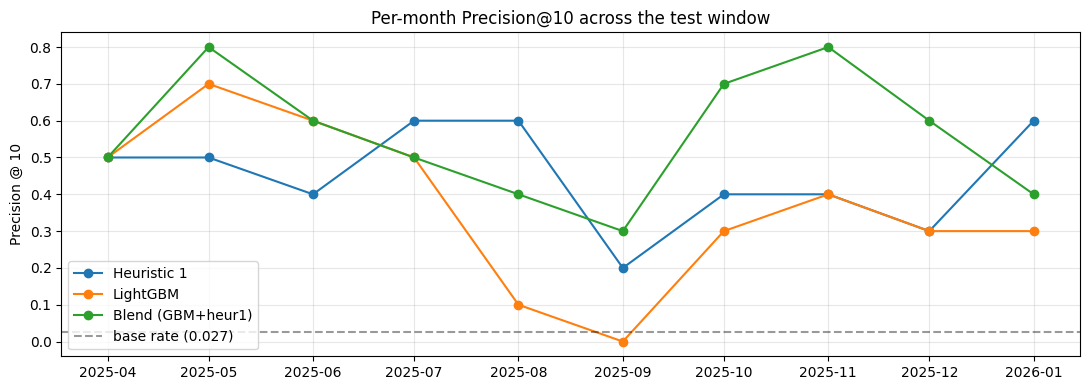

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, df in [
    ('Heuristic 1',       monthly_h1),
    ('LightGBM',          monthly_gbm),
    ('Blend (GBM+heur1)', monthly_blend),
]:
    ax.plot(df['observation_date'], df['precision_at_10'], marker='o', label=name)
ax.axhline(mean_base, color='k', linestyle='--', alpha=0.4, label=f'base rate ({mean_base:.3f})')
ax.set_ylabel('Precision @ 10')
ax.set_title('Per-month Precision@10 across the test window')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Findings & decisions

Distilled from the iteration log:

**1. Per-month vs pooled `P@K` is the metric to trust.** Pooled `P@10` was ~0.50 while per-month mean `P@10` was ~0.37 — that gap signals cross-month score scale issues, not a feature problem. The fix is rank-based, not feature-based.

**2. Monotone constraints + rank blending closed the heuristic gap** without sacrificing aggregate metrics. LambdaRank with monthly groups was attempted and abandoned — LightGBM caps groups at 10K rows, and the negative-downsampling workaround inflated validation NDCG while collapsing test precision through massive top-K ties.

**3. CIHI formulary numerics were a popularity trap.** `n_jurisdictions_on_formulary` and `n_programs_as_benefit` correlate strongly and act as a generic "this drug is broadly used" signal. Adding them collapsed cold-start `P@10` from 0.30 → 0.00 by pushing widely-listed drugs (which are mostly *not* in shortage) to the top of the cold-start ranking. They also extended LightGBM's `best_iteration_` from 52 → 111 and overfit top-K. **Decision:** keep the binary `formulary_is_generic` (clean drug-type marker, +0.18 P@10, +0.06 cold P@10) and drop the rest. The columns are still produced by dbt for future experimentation but excluded from `FEATURES`.

**4. Recall data was evaluated and skipped.** Health Canada's recalls CSV has no DIN column and only ~15 of 2,759 records embed one in the product field. The viable join (ATC4-level rollup via NLP ingredient parsing) is high effort for medium expected value — deferred until the formulary feature was proven out.

**5. CIHI prescribed drug spending is unusable.** 60-row province-level aggregate, no drug identifier — cannot join to DIN or ATC. CIHI high-cost drug spending (430K rows, ATC5) is the next likely add — it brings a novel "$ at risk" signal but only covers 2020+, so 2018–2019 training rows would have no signal.

## 8. Example predictions

Top-10 risk picks for the **most recent test month (2026-01)**, scored with the production blend (GBM + heuristic). Each row shows the model's rank, the actual outcome, and the features that drove the score.

In [12]:
import duckdb

test_with_score = test.copy()
test_with_score['blend_score'] = blend_scores
test_with_score['gbm_score']   = gbm_scores

latest_month = test_with_score['observation_date'].max()
month_slice = test_with_score[test_with_score['observation_date'] == latest_month].copy()

top10 = month_slice.nlargest(10, 'blend_score')[[
    'din', 'gbm_score',
    'shortages_prior_12m', 'shortages_all_prior',
    'days_since_last_shortage',
    'mfr_shortage_rate_12m',
    'atc_anatomic_group',
    'was_ever_in_shortage',
    dl.TARGET,
]].reset_index(drop=True)
top10.insert(0, 'rank', range(1, len(top10) + 1))

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    dins_csv = ','.join(f"'{d}'" for d in top10['din'].astype(str).tolist())
    name_lookup = con.sql(f"""
        SELECT din, ANY_VALUE(brand_name) AS brand, ANY_VALUE(company_name) AS manufacturer
        FROM main_intermediate.dim_drug_by_din
        WHERE din IN ({dins_csv})
        GROUP BY din
    """).df()

top10 = top10.merge(name_lookup, on='din', how='left')
print(f'Top-10 risk picks for observation_date = {pd.Timestamp(latest_month).date()}')
print(f'(positive label = shortage started within 90 days of obs date)\n')
top10[['rank', 'din', 'brand', 'manufacturer', 'atc_anatomic_group',
       'shortages_prior_12m', 'days_since_last_shortage',
       'mfr_shortage_rate_12m', 'gbm_score', dl.TARGET]]

Top-10 risk picks for observation_date = 2026-01-01
(positive label = shortage started within 90 days of obs date)



,rank,din,brand,manufacturer,atc_anatomic_group,shortages_prior_12m,days_since_last_shortage,mfr_shortage_rate_12m,gbm_score,shortage_started_within_90d
0,1,02293838,APO-LANSOPRAZOLE,APOTEX INC,A,7,37,0.2584,0.3492,1
1,2,02329794,KIT FOR THE PREPARATION OF TECHNETIUM TC 99M S...,CURIUM CANADA INC,V,4,22,0.6667,0.3135,0
2,3,02166720,SANDOZ TIMOLOL,SANDOZ CANADA INCORPORATED,S,4,73,0.3151,0.3116,0
3,4,02420171,SANDOZ OLOPATADINE 0.2%,SANDOZ CANADA INCORPORATED,S,4,73,0.3151,0.3006,0
4,5,02245523,"TARO-CLOBETASOL CREAM USP, 0.05%",TARO PHARMACEUTICALS INC,D,5,79,0.5451,0.2861,1
5,6,02246365,TRANEXAMIC ACID INJECTION BP,SANDOZ CANADA INCORPORATED,B,3,52,0.3151,0.3306,0
6,7,02245524,"TARO-CLOBETASOL OINTMENT USP, 0.05%",TARO PHARMACEUTICALS INC,D,6,29,0.5451,0.2810,0
7,8,02443449,MYLAN-NAPROXEN/ESOMEPRAZOLE MR,MYLAN PHARMACEUTICALS ULC,M,6,145,0.1437,0.2795,1
8,9,02326973,SANDOZ CANDESARTAN,SANDOZ CANADA INCORPORATED,C,6,45,0.3151,0.2752,1
9,10,00001732,XYLOCAINE 1%,ASPEN PHARMACARE CANADA INC.,N,3,42,0.2364,0.2874,0


In [13]:
hits = int(top10[dl.TARGET].sum())
n_pos_month = int(month_slice[dl.TARGET].sum())
n_drugs_month = len(month_slice)
print(f'Hits in top-10 for {pd.Timestamp(latest_month).date()}: {hits}/10 = {hits/10:.0%}')
print(f'Month base rate: {n_pos_month}/{n_drugs_month} = {n_pos_month/n_drugs_month:.2%}')
print(f'Lift over random: {(hits/10) / (n_pos_month/n_drugs_month):.1f}x')

Hits in top-10 for 2026-01-01: 4/10 = 40%
Month base rate: 462/14826 = 3.12%
Lift over random: 12.8x


### Cold-start example: drugs flagged with no prior shortage history

Most of the top-10 will be warm-start (the heuristic component pulls them up). To see what the model looks like *without* shortage history to lean on, here are the top-10 cold-start picks for the same month — drugs the model thinks are about to enter their **first** shortage.

In [14]:
cold_slice = month_slice[~month_slice['was_ever_in_shortage']].copy()
top10_cold = cold_slice.nlargest(10, 'gbm_score')[[
    'din', 'gbm_score',
    'mfr_shortage_rate_12m',
    'mfr_portfolio_size',
    'peer_shortages_prior_12m_same_ai_group',
    'competing_drugs_same_ai_group',
    'atc_anatomic_group',
    'drug_age_years',
    dl.TARGET,
]].reset_index(drop=True)
top10_cold.insert(0, 'rank', range(1, len(top10_cold) + 1))

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    dins_csv = ','.join(f"'{d}'" for d in top10_cold['din'].astype(str).tolist())
    cold_names = con.sql(f"""
        SELECT din, ANY_VALUE(brand_name) AS brand, ANY_VALUE(company_name) AS manufacturer
        FROM main_intermediate.dim_drug_by_din
        WHERE din IN ({dins_csv})
        GROUP BY din
    """).df()

top10_cold = top10_cold.merge(cold_names, on='din', how='left')
print(f'Top-10 cold-start risk picks for {pd.Timestamp(latest_month).date()}')
print(f'(no prior shortage anywhere in this DIN\'s history)\n')
top10_cold[['rank', 'din', 'brand', 'manufacturer', 'atc_anatomic_group',
            'mfr_shortage_rate_12m', 'peer_shortages_prior_12m_same_ai_group',
            'competing_drugs_same_ai_group', 'gbm_score', dl.TARGET]]

Top-10 cold-start risk picks for 2026-01-01
(no prior shortage anywhere in this DIN's history)



,rank,din,brand,manufacturer,atc_anatomic_group,mfr_shortage_rate_12m,peer_shortages_prior_12m_same_ai_group,competing_drugs_same_ai_group,gbm_score,shortage_started_within_90d
0,1,02541629,QUILLIVANT ER CHEWABLE TABLETS,KYE PHARMACEUTICALS INC.,N,0.3333,1,3.0000,0.1426,0
1,2,02284642,AZILECT,TEVA CANADA LIMITED,N,0.3327,2,3.0000,0.1268,0
2,3,02284650,AZILECT,TEVA CANADA LIMITED,N,0.3327,4,3.0000,0.1268,0
3,4,02553414,SANDOZ EDOXABAN,SANDOZ CANADA INCORPORATED,B,0.3151,1,2.0000,0.1182,0
4,5,02554208,TEVA-EDOXABAN,TEVA CANADA LIMITED,B,0.3327,1,2.0000,0.1116,0
5,6,02143933,ACETAMINOPHEN WITH CODEINE - CAPLET,TEVA CANADA LIMITED,N,0.3327,3,16.0000,0.1093,0
6,7,02482258,SANDOZ RIVAROXABAN,SANDOZ CANADA INCORPORATED,B,0.3151,4,15.0000,0.1019,1
7,8,02541637,QUILLIVANT ER ORAL SUSPENSION,KYE PHARMACEUTICALS INC.,N,0.3333,0,5.0000,0.1018,1
8,9,02553430,SANDOZ EDOXABAN,SANDOZ CANADA INCORPORATED,B,0.3151,1,4.0000,0.1015,0
9,10,02553422,SANDOZ EDOXABAN,SANDOZ CANADA INCORPORATED,B,0.3151,1,4.0000,0.1015,0


Notice how the cold-start picks are driven by **manufacturer** and **peer** signals: a stressed manufacturer's other DINs are flagged, and drugs whose ATC peers are already in shortage rise. The model has nothing else to go on — and that's exactly the regime where the heuristic falls silent (every drug here has `shortages_prior_12m = 0`).

## 9. Where this leaves us

**Current production state**
- Single LightGBM with monotone constraints + within-month rank blend with Heuristic 1.
- Per-month mean `P@10` ≈ 0.37, median 0.35, monthly range 0.1–0.6 across 10 test months.
- Pareto-dominates Heuristic 1 across `K ∈ {10, 25, 50, 100}`.
- 30 features, no FDA features in the unified model (still in panel for cold-start experiments).

**Open work, in priority order**
1. **CIHI high-cost drug spending** (ATC5, 2020+, 430K rows) — adds a novel `$ at risk` signal absent from current features. Modest implementation effort.
2. **Re-evaluate FDA ingredient features in cold-start.** Sparse by design but the only cross-border signal available; warrants a focused cold-start ablation rather than the unified model.
3. **Recall data via ATC4 ingredient rollup.** High effort (NLP ingredient parsing, no DIN column), medium expected value — defer until 1 and 2 land.